# 신용카드 채무불이행 고객 예측
## 서비스용 모델 생성 및 결과 해설 노트북

이 노트북은 연체확률예측서비스를 위한 모델 학습 과정을 정리한 문서다.  
핵심 모델은 **StandardScaler → PCA(10) → RandomForestClassifier** 구조이며,  
EDA부터 전처리, 분할, 학습, 평가, 중요도 해석, 하이퍼파라미터 튜닝, 서비스용 저장까지 한 흐름으로 구성했다.

### 분석 흐름
1. EDA  
2. 데이터 전처리  
3. Train / Test Split  
4. 모델 학습  
5. 모델 평가  
6. 피처 중요도 해석  
7. 하이퍼파라미터 튜닝  
8. 서비스 배포용 모델 저장 및 샘플 추론

In [1]:
# 필요 시 한 번만 실행
# !pip install xlrd

In [2]:
import os
import warnings
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    RocCurveDisplay
)
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
RANDOM_STATE = 42

## 1. 데이터 불러오기
- UCI Credit Card Default 데이터를 불러온다.
- 원본 xls가 없으면 자동 다운로드한다.

In [3]:
DATA_DIR = Path('./data')
DATA_DIR.mkdir(exist_ok=True)

xls_path = DATA_DIR / '../03_ml_data/tabular_datasets/UCI_Credit_Card.xls'
csv_path = DATA_DIR / '../03_ml_data/tabular_datasets/UCI_Credit_Card.csv'
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls'

if csv_path.exists():
    df = pd.read_csv(csv_path)
elif xls_path.exists():
    df = pd.read_excel(xls_path, header=1)
    df.to_csv(csv_path, index=False)
else:
    urllib.request.urlretrieve(url, xls_path)
    df = pd.read_excel(xls_path, header=1)
    df.to_csv(csv_path, index=False)

print('원본 데이터 크기 :', df.shape)
df.head()

원본 데이터 크기 : (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


### 결과 해설
- 원본 데이터는 **30,000행 × 25열**로 확인되었다.
- 서비스 입력에는 `ID`를 제외한 23개 변수와 타깃 변수가 사용된다.
- 표본 수가 충분해 기본적인 분류 모델 학습과 교차검증에 적합한 데이터 규모라고 볼 수 있다.

## 2. EDA
- 데이터 구조, 결측치, 기본 분포를 먼저 확인한다.
- 타깃 변수와 핵심 변수 분포를 빠르게 점검한다.
- 시각화를 통해 클래스 불균형과 주요 변수의 형태를 확인한다.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [5]:
df.isna().sum().sort_values(ascending=False).head(10)

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
dtype: int64

### 결과 해설
- `df.info()`와 결측치 확인 결과, **주요 컬럼에 결측치가 존재하지 않았다**.
- 따라서 이번 프로젝트의 핵심 전처리는 결측치 보정이 아니라,
  **서비스에서 사용할 피처를 고정하고 모델 입력 구조를 일관되게 맞추는 일**에 가깝다.
- 즉, 데이터 품질 자체는 비교적 안정적이며, 성능 차이는 모델 구조와 하이퍼파라미터에서 더 크게 발생할 가능성이 높다.

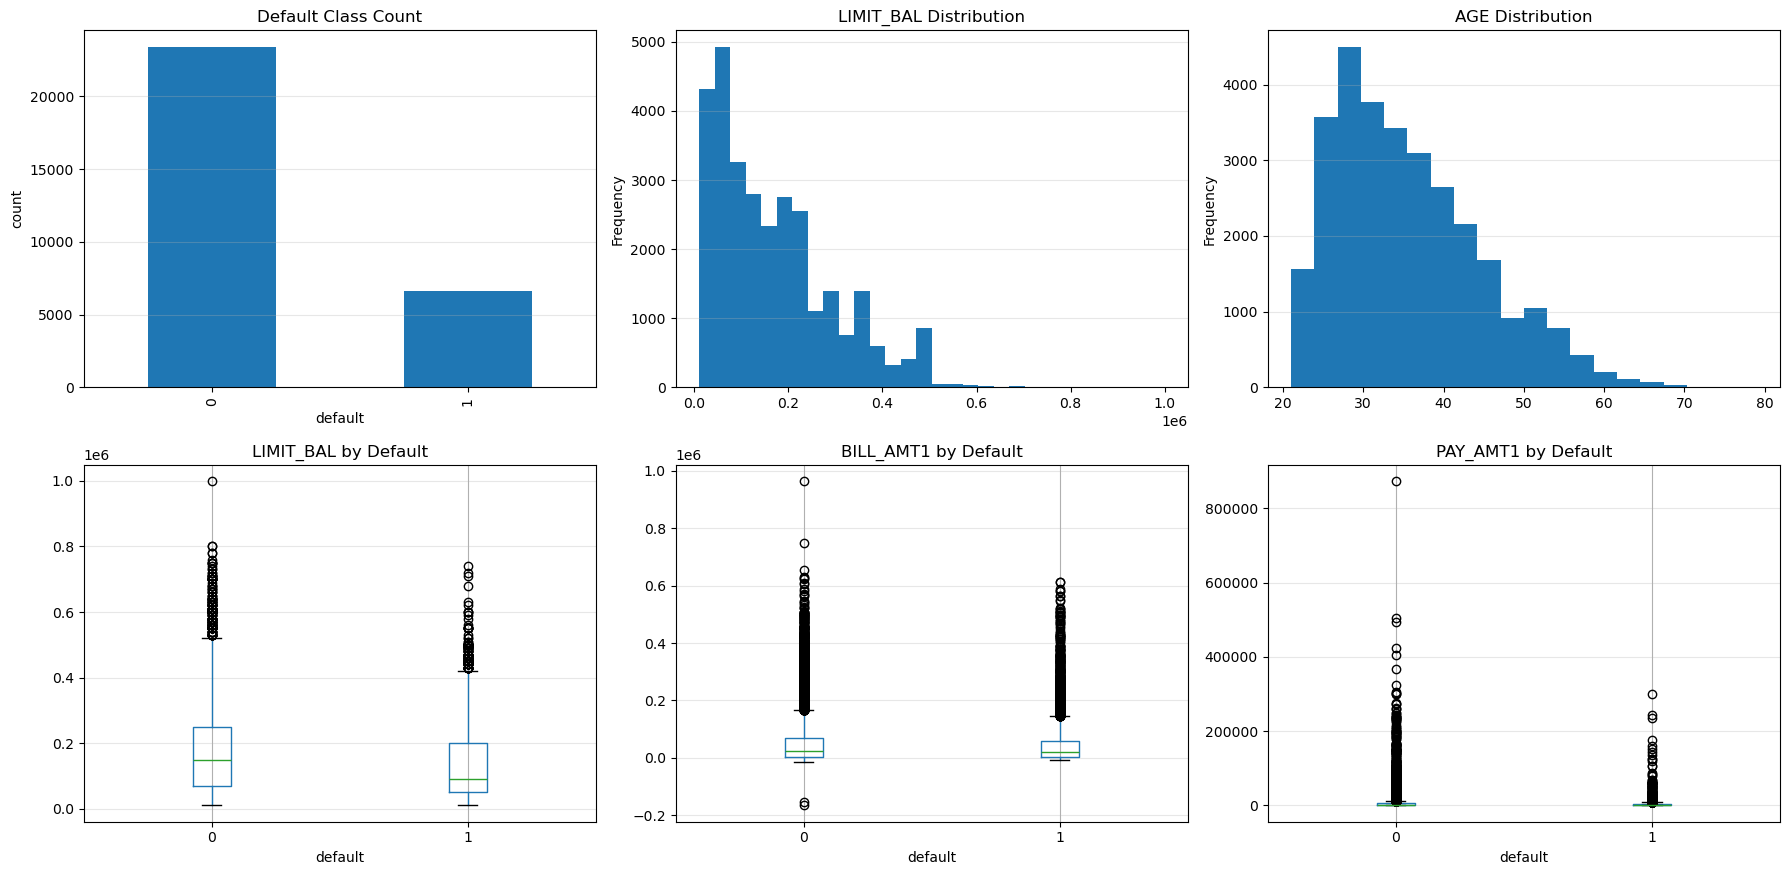

In [6]:
eda_df = df.copy()
if 'default payment next month' in eda_df.columns:
    eda_df = eda_df.rename(columns={'default payment next month': 'default'})

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

eda_df['default'].value_counts().sort_index().plot(kind='bar', ax=axes[0, 0], title='Default Class Count')
axes[0, 0].set_xlabel('default')
axes[0, 0].set_ylabel('count')
axes[0, 0].grid(axis='y', alpha=0.3)

eda_df['LIMIT_BAL'].plot(kind='hist', bins=30, ax=axes[0, 1], title='LIMIT_BAL Distribution')
axes[0, 1].grid(axis='y', alpha=0.3)

eda_df['AGE'].plot(kind='hist', bins=20, ax=axes[0, 2], title='AGE Distribution')
axes[0, 2].grid(axis='y', alpha=0.3)

eda_df.boxplot(column='LIMIT_BAL', by='default', ax=axes[1, 0])
axes[1, 0].set_title('LIMIT_BAL by Default')
axes[1, 0].set_xlabel('default')
axes[1, 0].grid(axis='y', alpha=0.3)

eda_df.boxplot(column='BILL_AMT1', by='default', ax=axes[1, 1])
axes[1, 1].set_title('BILL_AMT1 by Default')
axes[1, 1].set_xlabel('default')
axes[1, 1].grid(axis='y', alpha=0.3)

eda_df.boxplot(column='PAY_AMT1', by='default', ax=axes[1, 2])
axes[1, 2].set_title('PAY_AMT1 by Default')
axes[1, 2].set_xlabel('default')
axes[1, 2].grid(axis='y', alpha=0.3)

plt.suptitle('')
plt.tight_layout()
plt.show()

In [7]:
# 상관관계 히트맵 대체용 상위 상관쌍 확인
corr = eda_df.corr(numeric_only=True)['default'].drop('default').sort_values(key=np.abs, ascending=False)
corr.head(15).to_frame('corr_with_default')

,corr_with_default
PAY_0,0.3248
PAY_2,0.2636
PAY_3,0.2353
PAY_4,0.2166
PAY_5,0.2041
PAY_6,0.1869
LIMIT_BAL,-0.1535
PAY_AMT1,-0.0729
PAY_AMT2,-0.0586
PAY_AMT4,-0.0568


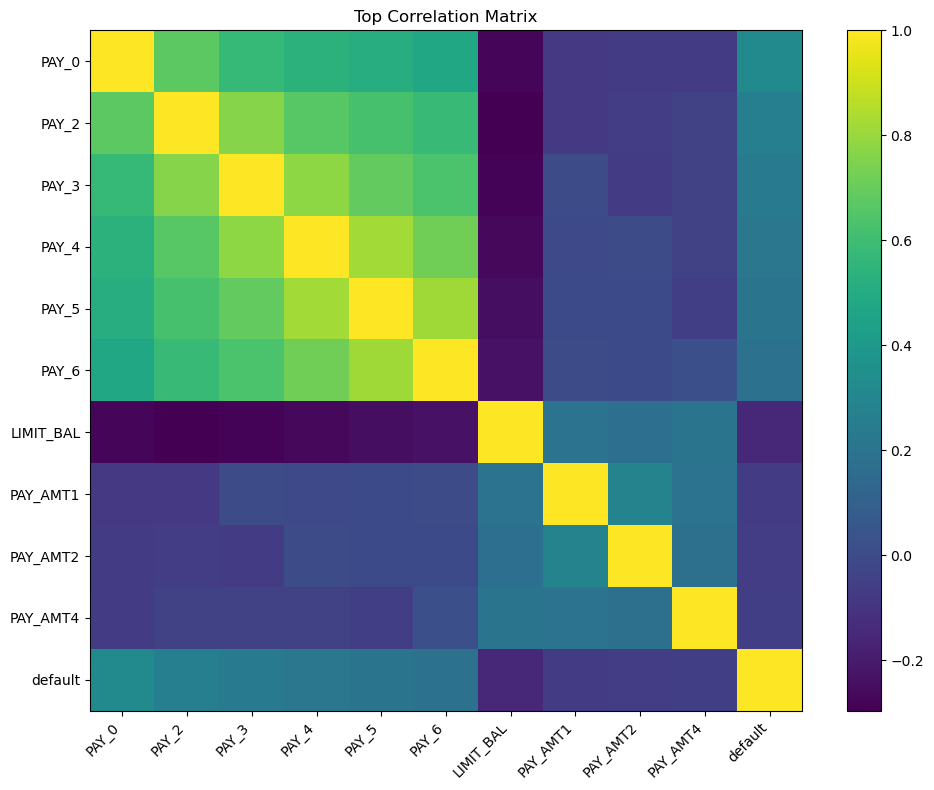

In [8]:
top_corr_cols = corr.head(10).index.tolist() + ['default']
corr_matrix = eda_df[top_corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, aspect='auto')
ax.set_xticks(range(len(top_corr_cols)))
ax.set_yticks(range(len(top_corr_cols)))
ax.set_xticklabels(top_corr_cols, rotation=45, ha='right')
ax.set_yticklabels(top_corr_cols)
ax.set_title('Top Correlation Matrix')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

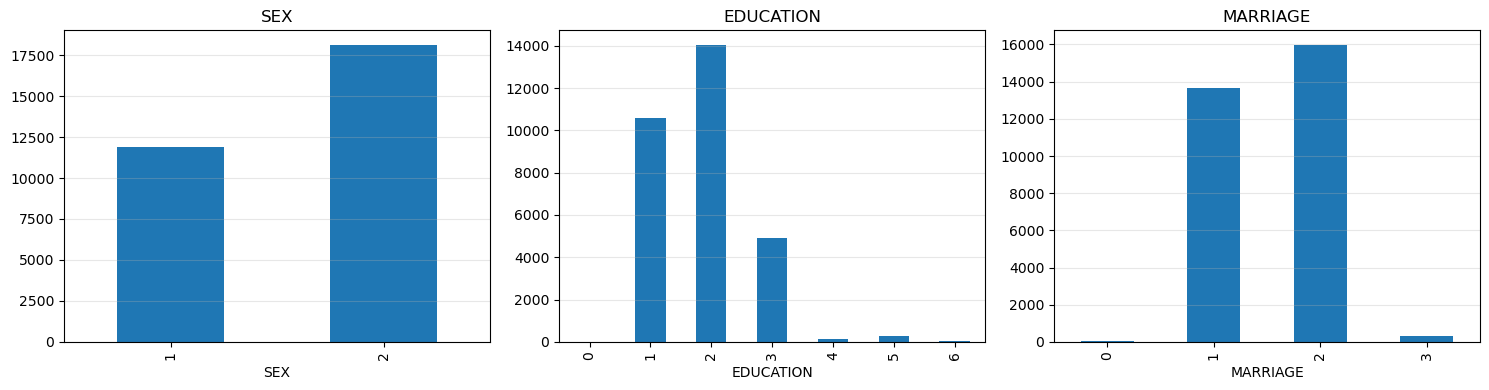

In [9]:
# 범주형 변수 기본 분포
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

eda_df['SEX'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='SEX')
axes[0].grid(axis='y', alpha=0.3)

eda_df['EDUCATION'].value_counts().sort_index().plot(kind='bar', ax=axes[1], title='EDUCATION')
axes[1].grid(axis='y', alpha=0.3)

eda_df['MARRIAGE'].value_counts().sort_index().plot(kind='bar', ax=axes[2], title='MARRIAGE')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### EDA 요약
- 분포 시각화와 상관관계 확인 결과, 연체 여부와 가장 관련성이 큰 변수는 **상환 상태 변수(`PAY_0`, `PAY_2`, `PAY_3`, `PAY_4` 등)**였다.
- 이는 단순한 인구통계 변수보다 **최근 상환 이력**이 연체 예측에 더 직접적인 단서라는 점을 보여준다.
- 서비스 관점에서도 고객의 성별이나 결혼 여부보다, **직전 상환 행동과 청구·상환 패턴**이 더 중요한 입력이라는 해석이 가능하다.

## 3. 데이터 전처리
- 서비스에서 사용할 컬럼 23개를 기준으로 피처를 고정한다.
- ID 제거, 타깃명 변경, 숫자형 형변환을 수행한다.
- 범위 확인용 요약표를 만들어 이상치를 빠르게 점검한다.

In [10]:
card_df = df.copy()

if 'default payment next month' in card_df.columns:
    card_df = card_df.rename(columns={'default payment next month': 'default'})

if 'ID' in card_df.columns:
    card_df = card_df.drop(columns='ID')

feature_cols = [
    'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

card_df = card_df[feature_cols + ['default']].copy()

for col in feature_cols + ['default']:
    card_df[col] = pd.to_numeric(card_df[col], errors='coerce')

print('전처리 후 데이터 크기 :', card_df.shape)
print('총 결측치 수 :', int(card_df.isna().sum().sum()))
card_df.head()

전처리 후 데이터 크기 : (30000, 24)
총 결측치 수 : 0


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [11]:
range_summary = pd.DataFrame({
    'min': card_df[feature_cols].min(),
    'max': card_df[feature_cols].max(),
    'nunique': card_df[feature_cols].nunique()
}).sort_index()

range_summary.head(15)

,min,max,nunique
AGE,21,79,56
BILL_AMT1,-165580,964511,22723
BILL_AMT2,-69777,983931,22346
BILL_AMT3,-157264,1664089,22026
BILL_AMT4,-170000,891586,21548
BILL_AMT5,-81334,927171,21010
BILL_AMT6,-339603,961664,20604
EDUCATION,0,6,7
LIMIT_BAL,10000,1000000,81
MARRIAGE,0,3,4


In [12]:
# 타깃 비율 확인
target_ratio = card_df['default'].value_counts(normalize=True).sort_index().rename('ratio')
display(card_df['default'].value_counts().sort_index())
display(target_ratio)

default
0    23364
1     6636
Name: count, dtype: int64

default
0   0.7788
1   0.2212
Name: ratio, dtype: float64

### 타깃 분포 해설
- 정상 고객(`0`) 비율은 **77.88%**, 연체 고객(`1`) 비율은 **22.12%**로 나타났다.
- 즉, 데이터는 완전한 균형 상태는 아니며 **약한 클래스 불균형**을 가진다.
- 이런 구조에서는 정확도만 보면 모델이 좋아 보일 수 있으므로,
  **precision, recall, F1-score, ROC-AUC를 함께 확인**하는 것이 중요하다.

## 4. Train / Test Split
- 학습용과 테스트용 데이터를 분리한다.
- 클래스 비율 유지를 위해 stratify를 적용한다.

In [13]:
X = card_df[feature_cols].copy()
y = card_df['default'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('X_train :', X_train.shape)
print('X_test  :', X_test.shape)
print('y_train ratio')
display(y_train.value_counts(normalize=True).sort_index().rename('ratio'))

X_train : (24000, 23)
X_test  : (6000, 23)
y_train ratio


default
0   0.7788
1   0.2212
Name: ratio, dtype: float64

### 분할 해설
- 학습용 데이터는 **24,000건**, 테스트 데이터는 **6,000건**으로 나뉘었다.
- `stratify=y`를 적용했기 때문에 학습/테스트 모두에서 타깃 비율이 원본과 유사하게 유지되었다.
- 이는 평가 결과가 특정 데이터 쏠림 때문에 흔들리는 것을 줄여 준다.

## 5. 모델 학습
- 핵심 모델은 `StandardScaler → PCA(10) → RandomForestClassifier`로 구성한다.
- 비교를 위해 기준 모델도 함께 학습한다.

In [14]:
def evaluate_classifier(model, X_eval, y_eval):
    pred = model.predict(X_eval)
    proba = model.predict_proba(X_eval)[:, 1]

    result = {
        'accuracy': accuracy_score(y_eval, pred),
        'precision': precision_score(y_eval, pred, zero_division=0),
        'recall': recall_score(y_eval, pred, zero_division=0),
        'f1': f1_score(y_eval, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_eval, proba)
    }
    return result, pred, proba

def metric_frame(name, result):
    row = {'model': name}
    row.update(result)
    return pd.DataFrame([row])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

In [15]:
baseline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])

baseline_rf = Pipeline([
    ('rf', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

baseline_et = Pipeline([
    ('et', ExtraTreesClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

core_pca_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10, random_state=RANDOM_STATE)),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

models = {
    'LogisticRegression': baseline_lr,
    'RandomForest': baseline_rf,
    'ExtraTrees': baseline_et,
    'Core_PCA10_RF': core_pca_rf
}

In [16]:
cv_compare = []

for name, model in models.items():
    cv_result = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    cv_compare.append({
        'model': name,
        'cv_accuracy_mean': cv_result['test_accuracy'].mean(),
        'cv_precision_mean': cv_result['test_precision'].mean(),
        'cv_recall_mean': cv_result['test_recall'].mean(),
        'cv_f1_mean': cv_result['test_f1'].mean(),
        'cv_roc_auc_mean': cv_result['test_roc_auc'].mean()
    })

compare_df = pd.DataFrame(cv_compare).sort_values('cv_roc_auc_mean', ascending=False).reset_index(drop=True)
compare_df

,model,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean
0,RandomForest,0.8173,0.6644,0.3519,0.4600,0.7705
1,ExtraTrees,0.8125,0.6317,0.3658,0.4633,0.7606
2,Core_PCA10_RF,0.8030,0.6170,0.2884,0.3929,0.7387
3,LogisticRegression,0.6916,0.3833,0.6457,0.4809,0.7265


### 모델 비교 해설
교차검증 결과를 보면 다음과 같은 흐름을 읽을 수 있다.

- **RandomForest**는 정확도(**0.8173**)와 ROC-AUC(**0.7705**)가 가장 높아, 전체적인 분류 성능이 가장 우수했다.
- **ExtraTrees**는 F1-score(**0.4633**)가 가장 높아, 균형 잡힌 분류 성능 면에서 경쟁력이 있었다.
- **Core_PCA10_RF**는 이번 과제의 핵심 구조이기 때문에 비교 대상으로 유지했으며, 정확도(**0.8030**)와 ROC-AUC(**0.7387**)를 보였다.
- **LogisticRegression**은 recall(**0.6457**)이 높아 연체 고객을 놓치지 않는 측면은 강했지만, 정확도(**0.6916**)와 precision(**0.3833**)은 상대적으로 낮았다.

즉, **핵심 모델은 최고 성능 모델이라기보다, 차원 축소를 포함한 과제 요구 구조를 충족하는 모델**로 이해하는 것이 적절하다.

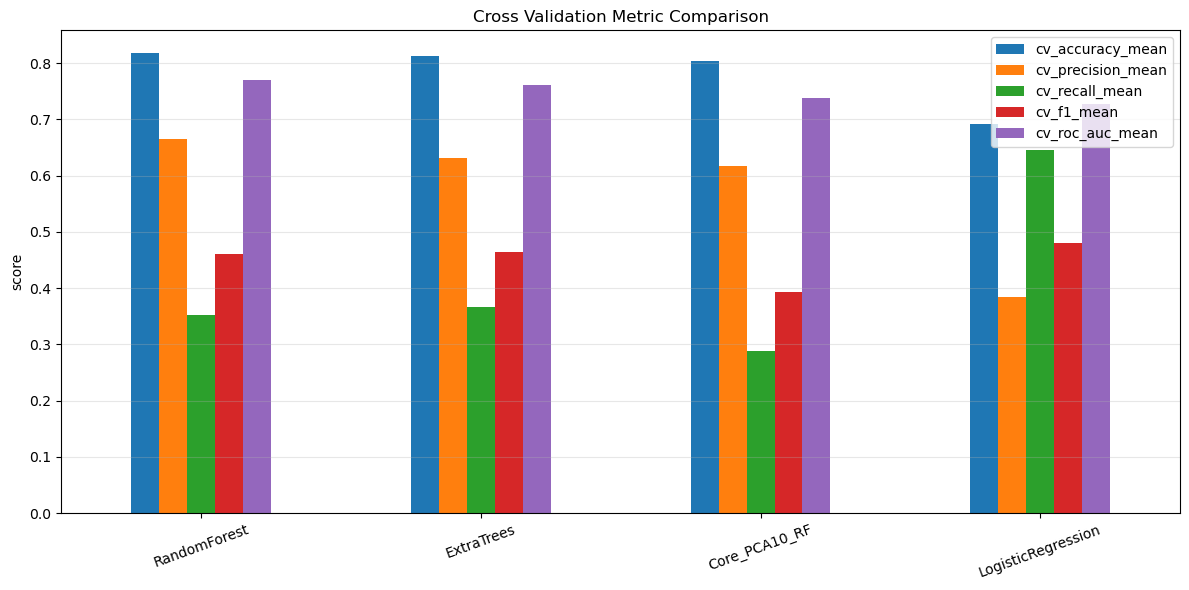

In [17]:
# 교차검증 결과 시각화
plot_cols = ['cv_accuracy_mean', 'cv_precision_mean', 'cv_recall_mean', 'cv_f1_mean', 'cv_roc_auc_mean']
ax = compare_df.set_index('model')[plot_cols].plot(kind='bar', figsize=(12, 6))
ax.set_title('Cross Validation Metric Comparison')
ax.set_ylabel('score')
ax.set_xlabel('')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [18]:
# 핵심 모델 학습
core_pca_rf.fit(X_train, y_train)
core_result, core_pred, core_proba = evaluate_classifier(core_pca_rf, X_test, y_test)

pd.DataFrame([core_result], index=['Core_PCA10_RF'])

,accuracy,precision,recall,f1,roc_auc
Core_PCA10_RF,0.7965,0.5849,0.2751,0.3742,0.7400


### 핵심 모델 1차 성능 해설
테스트셋 기준 핵심 모델의 성능은 다음과 같다.

- Accuracy: **0.7965**
- Precision: **0.5849**
- Recall: **0.2751**
- F1-score: **0.3742**
- ROC-AUC: **0.7400**

이 결과는 모델이 **전체 정확도는 준수하지만, 실제 연체 고객을 잡아내는 재현율(recall)은 낮은 편**임을 보여준다.  
서비스 관점에서 보면, 초기 모델은 정상 고객을 잘 구분하는 대신 **연체 고객 일부를 놓치는 보수적인 모델**이라고 해석할 수 있다.

## 6. 모델 평가
- 테스트셋 기준 성능을 확인한다.
- confusion matrix와 ROC curve를 시각화한다.

In [19]:
print(classification_report(y_test, core_pred, digits=4))

              precision    recall  f1-score   support

           0     0.8211    0.9446    0.8785      4673
           1     0.5849    0.2751    0.3742      1327

    accuracy                         0.7965      6000
   macro avg     0.7030    0.6098    0.6263      6000
weighted avg     0.7688    0.7965    0.7670      6000



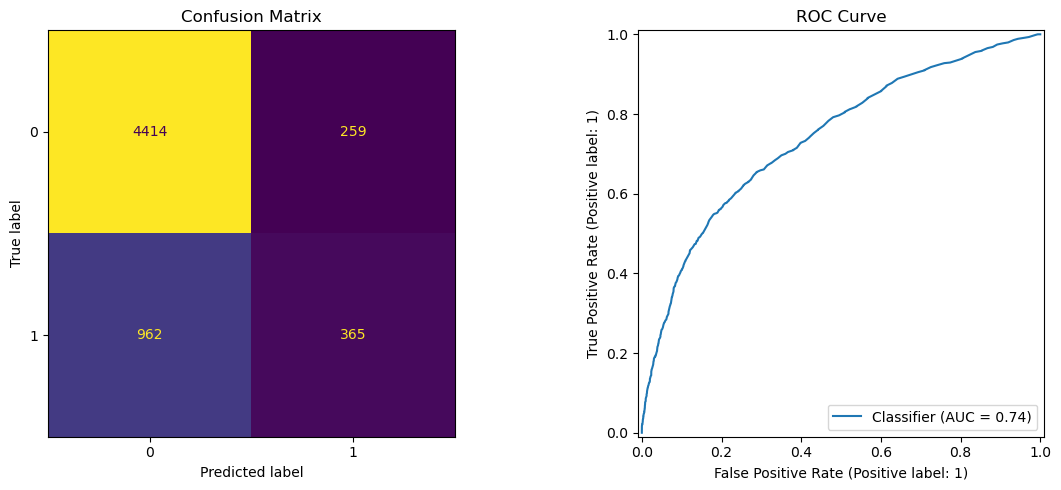

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, core_pred, ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, core_proba, ax=axes[1])
axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.show()

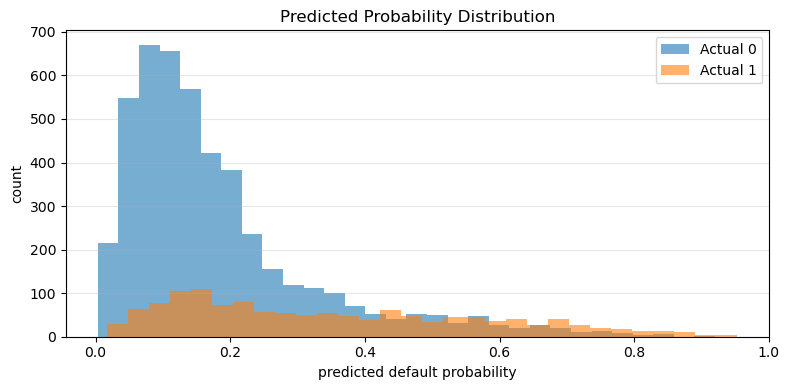

In [21]:
# 확률 분포 시각화
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(core_proba[y_test.values == 0], bins=30, alpha=0.6, label='Actual 0')
ax.hist(core_proba[y_test.values == 1], bins=30, alpha=0.6, label='Actual 1')
ax.set_title('Predicted Probability Distribution')
ax.set_xlabel('predicted default probability')
ax.set_ylabel('count')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### confusion matrix / ROC / 확률분포 해설
- 분류 리포트를 보면 정상 고객(0)에 대한 성능은 높다.  
  실제로 클래스 0의 recall은 **0.9446**으로 매우 높게 나타났다.
- 반면 연체 고객(1)의 recall은 **0.2751**이므로, 연체 고객 탐지력은 충분히 높지 않다.
- ROC-AUC가 **0.7400**이라는 점은 확률 순위화 능력은 어느 정도 확보했음을 의미한다.
- 따라서 이 단계의 핵심 과제는 "확률 자체는 어느 정도 분리하지만, 임계값과 파라미터 설정 때문에 연체 고객 탐지가 약하다"는 점이다.

즉, **튜닝의 목적은 단순 정확도 향상이 아니라 연체 고객 식별력 개선**에 두는 것이 더 적절하다.

## 7. 피처 중요도
- PCA를 사용한 모델은 원본 변수 기준 importance를 바로 해석하기 어렵다.
- 그래서 두 가지를 함께 본다.
  1. **PCA 축 중요도**
  2. **PCA 로딩을 가중 반영한 원본 변수 기여도(근사치)**

In [22]:
pca_model = core_pca_rf.named_steps['pca']
rf_model = core_pca_rf.named_steps['rf']

pc_importance = pd.DataFrame({
    'principal_component': [f'PC{i+1}' for i in range(pca_model.n_components_)],
    'rf_importance': rf_model.feature_importances_,
    'explained_variance_ratio': pca_model.explained_variance_ratio_
}).sort_values('rf_importance', ascending=False)

pc_importance

,principal_component,rf_importance,explained_variance_ratio
1,PC2,0.2124,0.1788
0,PC1,0.1095,0.2848
8,PC9,0.0919,0.0359
2,PC3,0.0911,0.0686
9,PC10,0.0898,0.0332
4,PC5,0.0831,0.0445
7,PC8,0.0822,0.0384
3,PC4,0.0815,0.0648
5,PC6,0.0800,0.0420
6,PC7,0.0785,0.0398


### PCA 축 중요도 해설
RandomForest는 PCA로 변환된 10개의 주성분을 입력으로 받기 때문에,  
먼저 어떤 주성분이 예측에 더 크게 기여했는지 확인할 수 있다.

- 가장 영향력이 큰 축은 **PC2(0.2124)**였고,
- 그 다음은 **PC1(0.1095)**였다.

한편 설명분산비율은
- **PC1 = 28.48%**
- **PC2 = 17.88%**
로 나타났다.

즉, 데이터 분산을 가장 많이 설명하는 축과 예측에 가장 많이 기여한 축이 완전히 같지는 않다.  
이는 **차원 축소에서 정보량이 큰 축이 항상 분류에 가장 유리한 축은 아니라는 점**을 보여준다.

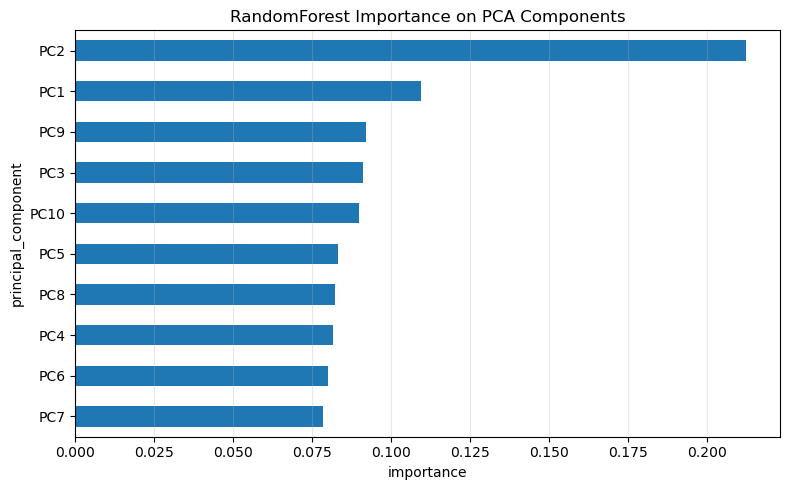

In [23]:
# PCA 축 중요도 시각화
ax = pc_importance.set_index('principal_component')['rf_importance'].sort_values().plot(
    kind='barh',
    figsize=(8, 5)
)
ax.set_title('RandomForest Importance on PCA Components')
ax.set_xlabel('importance')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# 원본 변수 기준 근사 중요도 계산
loading_abs = np.abs(pca_model.components_.T)  # (원본변수 수, PC 수)
weighted_importance = loading_abs @ rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'approx_importance': weighted_importance
}).sort_values('approx_importance', ascending=False).reset_index(drop=True)

feature_importance_df.head(15)

,feature,approx_importance
0,PAY_AMT6,0.2271
1,PAY_AMT4,0.2269
2,PAY_AMT5,0.2190
3,PAY_AMT3,0.2120
4,EDUCATION,0.2021
5,PAY_AMT1,0.1935
6,PAY_AMT2,0.1830
7,LIMIT_BAL,0.1464
8,PAY_5,0.1418
9,PAY_4,0.1401


### 원본 변수 기준 근사 중요도 해설
PCA를 사용하면 원본 피처 중요도를 직접 읽기 어렵기 때문에,  
여기서는 **주성분 loading과 RandomForest 중요도를 결합한 근사 방식**으로 원본 변수의 영향도를 해석했다.

상위 변수는 다음과 같다.
- `PAY_AMT6` (**0.2271**)
- `PAY_AMT4` (**0.2269**)
- `PAY_AMT5` (**0.2190**)
- `PAY_AMT3` (**0.2120**)
- `EDUCATION` (**0.2021**)

특히 `PAY_AMT` 계열이 상위권에 몰려 있다는 점은,  
**최근 실제 상환금액 패턴이 연체확률 예측에 강한 단서**가 된다는 해석을 가능하게 한다.

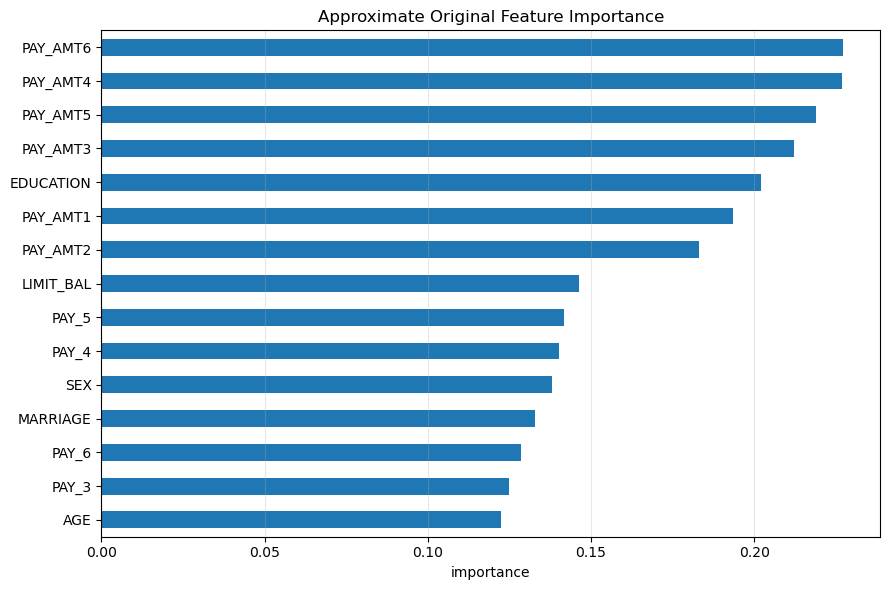

In [25]:
ax = feature_importance_df.head(15).sort_values('approx_importance').plot(
    x='feature',
    y='approx_importance',
    kind='barh',
    figsize=(9, 6),
    legend=False
)
ax.set_title('Approximate Original Feature Importance')
ax.set_xlabel('importance')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

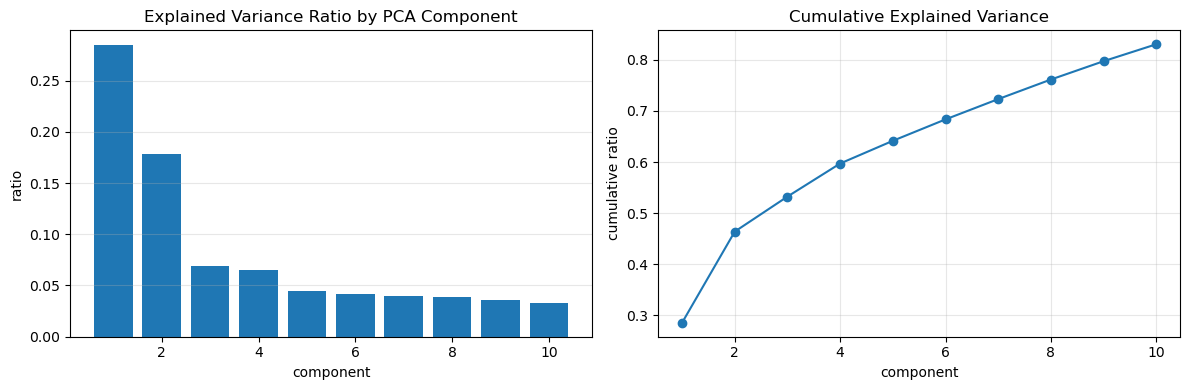

In [26]:
# PCA 설명분산 시각화
explained = pca_model.explained_variance_ratio_
cum_explained = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(explained) + 1), explained)
axes[0].set_title('Explained Variance Ratio by PCA Component')
axes[0].set_xlabel('component')
axes[0].set_ylabel('ratio')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(range(1, len(cum_explained) + 1), cum_explained, marker='o')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('component')
axes[1].set_ylabel('cumulative ratio')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### PCA 설명력 해설
10개 주성분의 누적 설명력은 **약 83.08%**로 확인된다.  
즉, 원본 23개 변수를 10개 축으로 줄였지만 데이터의 주요 분산 정보 대부분은 유지했다고 볼 수 있다.

따라서 이번 구조는
- 차원을 줄여 입력 구조를 단순화하고
- 과제 요구사항을 충족하면서도
- 정보 손실을 과도하게 만들지 않는  
절충안으로 해석할 수 있다.

## 8. 하이퍼파라미터 튜닝
- 핵심 구조는 유지한다.
- 즉, `StandardScaler → PCA(10) → RandomForestClassifier` 틀은 그대로 두고 RandomForest 중심으로 튜닝한다.

In [27]:
tuning_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=10, random_state=RANDOM_STATE)),
    ('rf', RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_distributions = {
    'rf__n_estimators': [200, 300, 400, 500, 700],
    'rf__max_depth': [None, 5, 7, 10, 15, 20],
    'rf__min_samples_split': [2, 5, 10, 20],
    'rf__min_samples_leaf': [1, 2, 4, 8],
    'rf__max_features': ['sqrt', 'log2', None]
}

search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print('Best CV ROC-AUC :', round(search.best_score_, 4))
print('Best Params :')
search.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV ROC-AUC : 0.7542
Best Params :


{'rf__n_estimators': 700,
 'rf__min_samples_split': 20,
 'rf__min_samples_leaf': 8,
 'rf__max_features': None,
 'rf__max_depth': 15}

### 튜닝 설정 해설
하이퍼파라미터 튜닝에서는 핵심 구조를 유지했다.

- `StandardScaler`
- `PCA(n_components=10)`
- `RandomForestClassifier`

그리고 RandomizedSearchCV를 통해 다음과 같은 최적 파라미터를 찾았다.

- `n_estimators = 700`
- `max_depth = 15`
- `min_samples_split = 20`
- `min_samples_leaf = 8`
- `max_features = None`

교차검증 기준 Best ROC-AUC는 **0.7542**로, 기본 모델보다 개선된 모습을 보였다.

In [28]:
best_model = search.best_estimator_
best_result, best_pred, best_proba = evaluate_classifier(best_model, X_test, y_test)

tuned_compare = pd.concat([
    pd.DataFrame([core_result], index=['Before_Tuning']),
    pd.DataFrame([best_result], index=['After_Tuning'])
])

tuned_compare

,accuracy,precision,recall,f1,roc_auc
Before_Tuning,0.7965,0.5849,0.2751,0.3742,0.7400
After_Tuning,0.7838,0.5118,0.4913,0.5013,0.7543


### 튜닝 전후 성능 비교 해설
튜닝 전후 테스트셋 성능은 다음과 같다.

**튜닝 전**
- Accuracy: **0.7965**
- Precision: **0.5849**
- Recall: **0.2751**
- F1-score: **0.3742**
- ROC-AUC: **0.7400**

**튜닝 후**
- Accuracy: **0.7838**
- Precision: **0.5118**
- Recall: **0.4913**
- F1-score: **0.5013**
- ROC-AUC: **0.7543**

해석하면, 튜닝 후에는 정확도와 precision이 조금 내려간 대신  
**recall이 크게 상승했고, F1-score와 ROC-AUC도 개선**되었다.

이는 서비스 목적상 더 의미 있는 변화다.  
왜냐하면 연체예측서비스에서는 정상 고객을 더 맞히는 것보다,  
**위험 고객을 놓치지 않는 것**이 더 중요하기 때문이다.

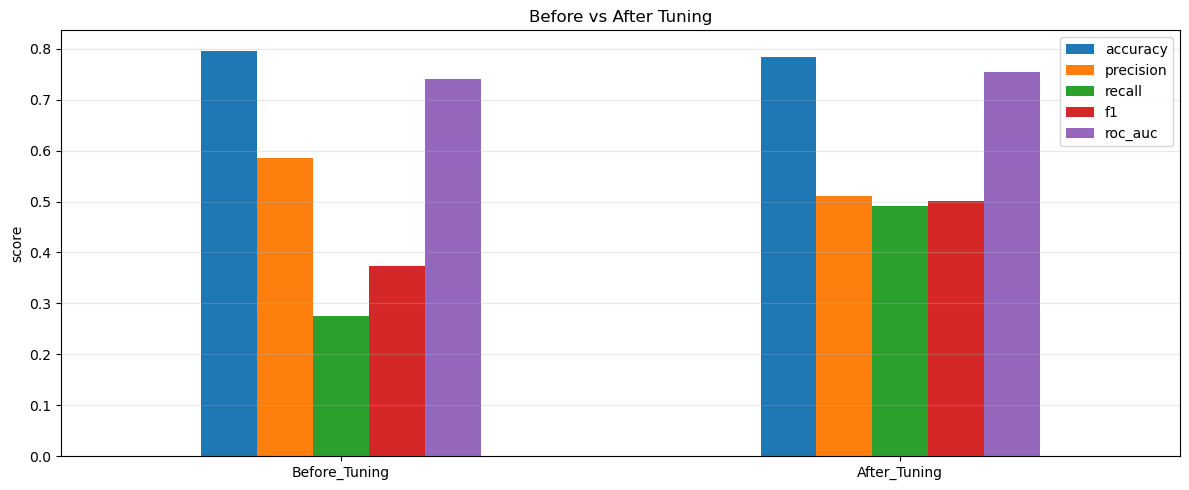

In [29]:
# 튜닝 전후 비교 시각화
ax = tuned_compare.plot(kind='bar', figsize=(12, 5))
ax.set_title('Before vs After Tuning')
ax.set_ylabel('score')
ax.set_xlabel('')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

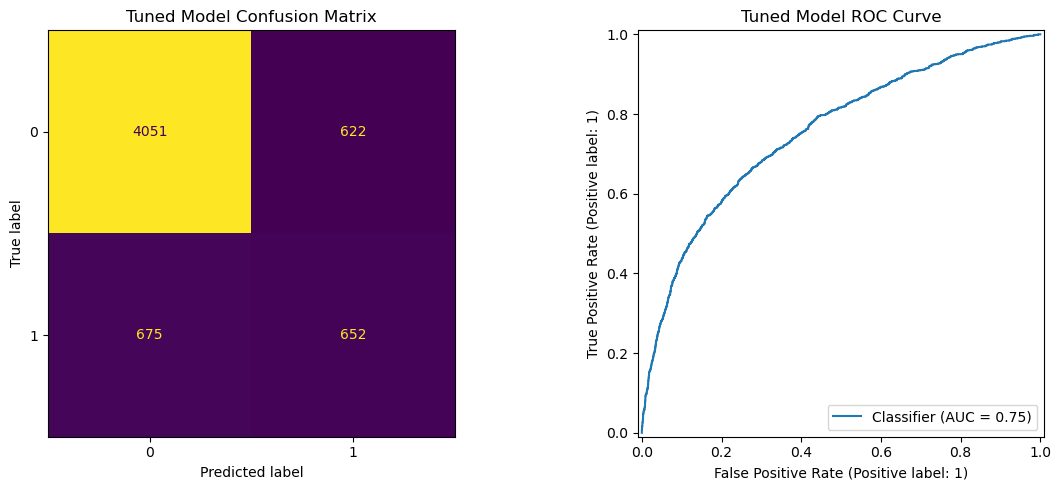

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, best_pred, ax=axes[0], colorbar=False)
axes[0].set_title('Tuned Model Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, best_proba, ax=axes[1])
axes[1].set_title('Tuned Model ROC Curve')

plt.tight_layout()
plt.show()

## 9. 서비스 배포용 산출물 저장
- 최종 모델을 `credit_pipeline.pkl`로 저장한다.
- 앱에서는 이 파일을 직접 로드해 `predict_proba()`를 사용하면 된다.

In [31]:
joblib.dump(best_model, 'credit_pipeline.pkl')
print('저장 완료:', os.path.abspath('credit_pipeline.pkl'))

저장 완료: c:\Users\Admin\hipython\ml\credit_pipeline.pkl


### 배포용 모델 저장 해설
최종 모델은 `credit_pipeline.pkl`로 저장했다.  
이 파일 하나만 교체하면 서비스 모델을 업데이트할 수 있으므로, 유지보수성 측면에서도 요구사항과 잘 맞는다.

In [32]:
# 서비스 연결 확인용 샘플 추론
def risk_grade(prob):
    if prob < 0.20:
        return '안전', '한도 증액 가능'
    elif prob < 0.40:
        return '주의', '모니터링 필요'
    elif prob < 0.60:
        return '경고', '한도 축소 검토'
    else:
        return '위험', '한도 정지 또는 추심 검토'

sample_input = X_test.iloc[[0]].copy()
sample_prob = float(best_model.predict_proba(sample_input)[0, 1])
sample_grade, sample_action = risk_grade(sample_prob)

print('예측 확률 :', round(sample_prob, 4))
print('위험 등급 :', sample_grade)
print('권장 조치 :', sample_action)

sample_input

예측 확률 : 0.3928
위험 등급 : 주의
권장 조치 : 모니터링 필요


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
6907,50000,1,2,2,46,-1,-1,-1,-1,0,0,1540,26060,0,2650,3320,2764,26060,0,3472,2320,1764,2841


## 10. 서비스 관점 최종 해석

샘플 추론 결과, 예측 확률은 **0.3928 (39.28%)**였고  
위험 등급은 **주의**, 권장 조치는 **모니터링 필요**로 분류되었다.

### 최종 결론
- 이번 프로젝트는 `StandardScaler → PCA(10) → RandomForestClassifier` 구조를 중심으로 연체확률예측서비스에 연결 가능한 파이프라인을 구축했다.
- 초기 핵심 모델은 정확도는 준수했지만 재현율이 낮았고, 튜닝을 통해 **연체 고객 탐지력(recall)**을 상당 부분 개선했다.
- 또한 모델을 `credit_pipeline.pkl` 형태로 저장해, 스트림릿 대시보드에서 바로 `predict_proba()`에 연결할 수 있는 상태까지 만들었다.

### 서비스 관점 요약
- **장점**: 서비스 연결이 쉬운 파이프라인 구조, 10개 주성분으로 단순화된 입력, ROC-AUC 개선
- **한계**: PCA 사용으로 원본 변수 해석력이 낮아지고, 정확도와 recall 사이의 trade-off가 존재
- **실무적 해석**: 단순 "맞춘 비율"보다, 위험 고객을 더 많이 포착하도록 조정된 모델이 실제 운영 목적에 더 적합하다